Midterm Project Call center Stats

In [349]:
!pip install openpyxl

****** Importing data and Performing the EDA process review Data and understand it. ******

**** Plan is to find if ML predict average call length using call type or FTE ******

In [394]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # makes creating  plots easier.

# Load the dataset directly from a URL
df = pd.read_excel('https://github.com/globalsmile/Call-Center-Analysis/raw/main/01%20Call-Center-Dataset.xlsx')

print("--- First 5 Rows ---")
print(df.head())
print("--- Last 5 Rows ---")
print(df.tail())


--- First 5 Rows ---
  Call Id    Agent        Date      Time              Topic Answered (Y/N)  \
0  ID0001    Diane  2021-01-01  09:12:58   Contract related              Y   
1  ID0002    Becky  2021-01-01  09:12:58  Technical Support              Y   
2  ID0003  Stewart  2021-01-01  09:47:31   Contract related              Y   
3  ID0004     Greg  2021-01-01  09:47:31   Contract related              Y   
4  ID0005    Becky  2021-01-01  10:00:29    Payment related              Y   

  Resolved  Speed of answer in seconds AvgTalkDuration  Satisfaction rating  
0        Y                       109.0        00:02:23                  3.0  
1        N                        70.0        00:04:02                  3.0  
2        Y                        10.0        00:02:11                  3.0  
3        Y                        53.0        00:00:37                  2.0  
4        Y                        95.0        00:01:00                  3.0  
--- Last 5 Rows ---
     Call Id  Agent   

In [351]:
# At a glance based on the head and tail of the dataset, we can see that there are some missing values in the 'Satisfaction rating','Speed of Answer', and 'AvgTalkDuration' column. Let's check for missing values in each column to confirm this.  
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum()) # Check for missing values in each column to confirm our observation from the head and tail of the dataset.

--- Missing Values Before Cleaning ---
Call Id                         0
Agent                           0
Date                            0
Time                            0
Topic                           0
Answered (Y/N)                  0
Resolved                        0
Speed of answer in seconds    946
AvgTalkDuration               946
Satisfaction rating           946
dtype: int64


In [352]:
# checking the shape and info of the dataset to get a better understanding of the data types and the number of non-null values in each column.
print("--- Dataset Shape ---")
print(df.shape)
print("--- Dataset Info ---")
print(df.info)

--- Dataset Shape ---
(5000, 10)
--- Dataset Info ---
<bound method DataFrame.info of      Call Id    Agent        Date      Time              Topic Answered (Y/N)  \
0     ID0001    Diane  2021-01-01  09:12:58   Contract related              Y   
1     ID0002    Becky  2021-01-01  09:12:58  Technical Support              Y   
2     ID0003  Stewart  2021-01-01  09:47:31   Contract related              Y   
3     ID0004     Greg  2021-01-01  09:47:31   Contract related              Y   
4     ID0005    Becky  2021-01-01  10:00:29    Payment related              Y   
...      ...      ...         ...       ...                ...            ...   
4995  ID4996      Jim  2021-03-31  16:37:55    Payment related              Y   
4996  ID4997    Diane  2021-03-31  16:45:07    Payment related              Y   
4997  ID4998    Diane  2021-03-31  16:53:46    Payment related              Y   
4998  ID4999      Jim  2021-03-31  17:02:24          Streaming              Y   
4999  ID5000    Diane  

In [353]:
df.dtypes # Checking the data types of each column

Call Id                           str
Agent                             str
Date                              str
Time                           object
Topic                             str
Answered (Y/N)                    str
Resolved                          str
Speed of answer in seconds    float64
AvgTalkDuration                object
Satisfaction rating           float64
dtype: object

In [354]:
df.describe() # Getting summary statistics for the numerical columns in the dataset

,Speed of answer in seconds,Satisfaction rating
count,4054.000000,4054.000000
mean,67.520720,3.403552
std,33.592872,1.212220
min,10.000000,1.000000
25%,39.000000,3.000000
50%,68.000000,3.000000
75%,97.000000,4.000000
max,125.000000,5.000000


In [355]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['Call Id'].value_counts()

Call Id
ID0001    1
ID0002    1
ID0003    1
ID0004    1
ID0005    1
         ..
ID4996    1
ID4997    1
ID4998    1
ID4999    1
ID5000    1
Name: count, Length: 5000, dtype: int64

*** Call ID is unneeded for my model since it has nothing to do performance.Will Drop***

In [356]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['Agent'].value_counts()

Agent
Jim        666
Martha     638
Diane      633
Dan        633
Becky      631
Greg       624
Joe        593
Stewart    582
Name: count, dtype: int64

***Agents are a string need to use encode to for model to understand***

In [357]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['Date'].value_counts()

Date
2021-01-11    84
2021-01-30    80
2021-02-03    74
2021-03-11    74
2021-02-01    72
              ..
2021-01-20    40
2021-03-28    38
2021-02-02    36
2021-03-31    27
2021-03-30    25
Name: count, Length: 90, dtype: int64

***Need to breakdown by Day of Week will have to encode and add column***

In [358]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['Time'].value_counts()

Time
11:55:41    30
15:21:36    30
11:42:43    28
12:00:00    28
11:12:29    28
            ..
15:07:12     4
10:36:29     4
14:06:43     4
17:51:22     4
12:08:38     2
Name: count, Length: 375, dtype: int64

***Unneeded columns that we can drop: 'Call Id', 'Agent', 'Date', 'Time' since they are not relevant to our analysis and may not contribute to the predictive power of our model. We will drop these columns in the data cleaning step.***

In [359]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['Topic'].value_counts()

Topic
Streaming            1022
Technical Support    1019
Payment related      1007
Contract related      976
Admin Support         976
Name: count, dtype: int64

***Topics are a string need to use encode to for model to understand***

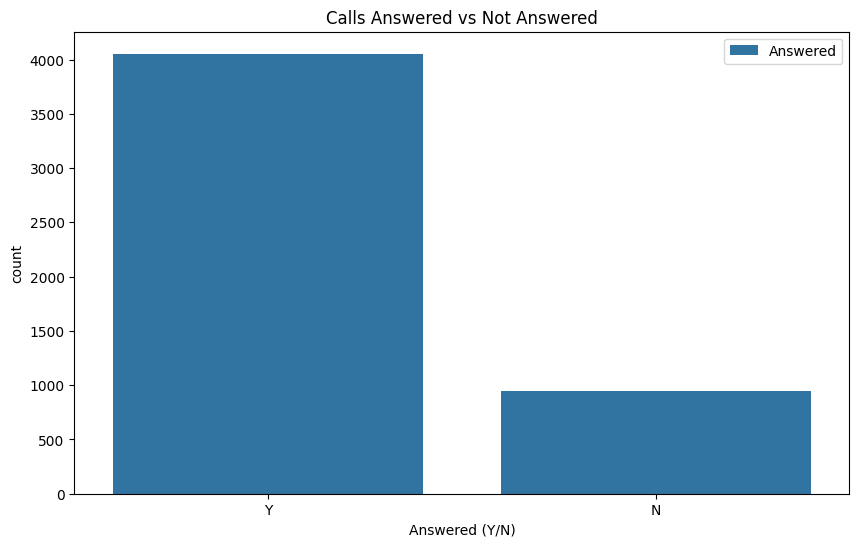

In [360]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['Answered (Y/N)'].value_counts()
plt.figure(figsize=(10, 6))
sns.countplot(x='Answered (Y/N)', data=df)
plt.title('Calls Answered vs Not Answered')
plt.legend(['Answered', 'Not Answered'])
plt.show()

******Redid countplot since I wanted more detail on the exact count****

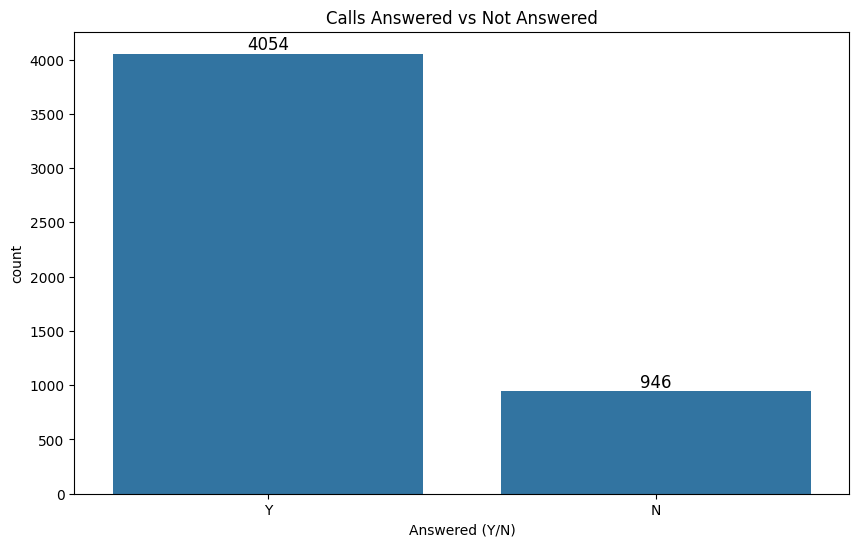

In [361]:
plt.figure(figsize=(10, 6))   # Set the figure size for better visibility
ax = sns.countplot(x='Answered (Y/N)', data=df)

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),        # the count number
        (p.get_x() + p.get_width() / 2, p.get_height()),  # position
        ha='center', va='bottom',        # alignment
        fontsize=12
    )

plt.title('Calls Answered vs Not Answered')
plt.show()

***** The answer columns aligns the missing data we had earlier with Speed of answer in seconds,AvgTalkDuration,Satisfaction rating all missing 946. Of course if the call was never answered in the first place it wouldn't have that data. For the sake of this model I'm needing information of overall perfomance based on what was recieved however the data maybe useful for a model about overall staffing to see where their are shortages in staffing needs I will need to exclude the Not answered *****

In [362]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['Resolved'].value_counts()

Resolved
Y    3646
N    1354
Name: count, dtype: int64

**** Will want to see addtional infomation visually about the Resolved v NonResolved is there a topic that skews higher something like that could affect satisfaction, Call duration******

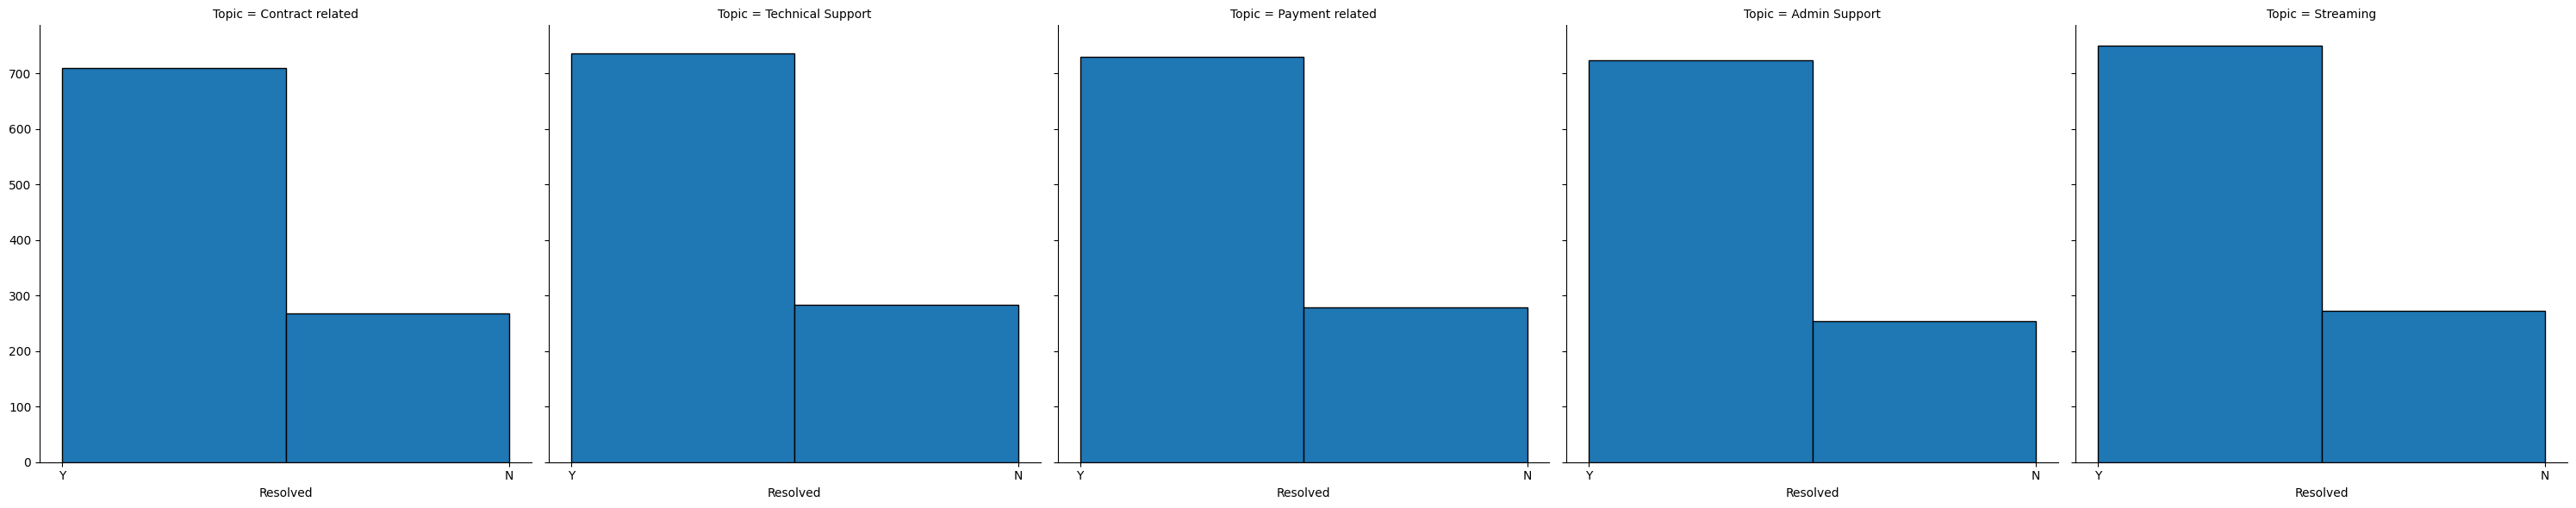

In [363]:
g = sns.FacetGrid(df, col='Topic', height=6)
g.map(plt.hist, 'Resolved', bins=2, edgecolor='black')
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),        # the count number
        (p.get_x() + p.get_width() / 2, p.get_height()),  # position
        ha='center', va='bottom',        # alignment
        fontsize=12
    )
plt.show()


**** Chart appears to be useless since all columns are the same likely to to value being string will need to encode****

In [364]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['Speed of answer in seconds'].value_counts()

Speed of answer in seconds
53.0     53
84.0     49
124.0    48
24.0     46
116.0    46
         ..
38.0     26
67.0     26
25.0     25
49.0     24
66.0     19
Name: count, Length: 116, dtype: int64

In [365]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['AvgTalkDuration'].value_counts()

AvgTalkDuration
00:04:43    22
00:02:11    21
00:05:43    19
00:06:15    18
00:02:44    18
            ..
00:06:27     4
00:04:34     4
00:02:28     4
00:05:38     3
00:00:30     3
Name: count, Length: 391, dtype: int64

In [366]:
df.describe() # Getting addtional details about the column. To see redundant/unnecessary columns that we can drop later on.
df['Satisfaction rating'].value_counts()

Satisfaction rating
3.0    1218
4.0    1180
5.0     843
1.0     417
2.0     396
Name: count, dtype: int64

Now that all columns have been reviewed I am working  on preparing the Data

***Unneeded columns that we can drop: 'Call Id', 'Agent', 'Date', 'Time' since they are not relevant to our analysis and may not contribute to the predictive power of our model. We will drop these columns in the data cleaning step. Will replace strings with encode for Agent and Date as well as assigning numerical values for the others strings ie. Topic, Answered (Y/N) and resolved.

Need to clean AvgTalkDuration and date to day of week and drop unneeded infomation and encode strings

In [ ]:
# 1. Date first, before anything else touches df
df['Date'] = pd.to_datetime(df['Date'], format='mixed').dt.day_name()

# 2. Then AvgTalkDuration
df['AvgTalkDuration'] = df['AvgTalkDuration'].apply(time_to_seconds)

# 3. Then drops and filtering
df = df.drop(columns=['Call Id', 'Time'])
df = df[df['Answered (Y/N)'] != 'N']
df = df.drop(columns=['Answered (Y/N)'])

# 4. Encode last
encoded_df = pd.get_dummies(df, columns=['Agent', 'Date', 'Topic', 'Resolved'], drop_first=True)


In [384]:
encoded_df.head() #viewing the first 5 rows of the encoded dataset to confirm that the encoding process was successful and to see how the categorical variables have been transformed into numerical format.

,Speed of answer in seconds,AvgTalkDuration,Satisfaction rating,Agent_Dan,Agent_Diane,Agent_Greg,Agent_Jim,Agent_Joe,Agent_Martha,Agent_Stewart,...,Date_Saturday,Date_Sunday,Date_Thursday,Date_Tuesday,Date_Wednesday,Topic_Contract related,Topic_Payment related,Topic_Streaming,Topic_Technical Support,Resolved_Y
0,109.0,143.0,3.0,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,70.0,242.0,3.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,10.0,131.0,3.0,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,True
3,53.0,37.0,2.0,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
4,95.0,60.0,3.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


In [396]:
from sklearn.linear_model import LinearRegression
# 1. Define Features
X = encoded_df.drop(columns=['AvgTalkDuration'])  # only drop the target
y = encoded_df['AvgTalkDuration']

# 2. Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Check the accuracy
print(f"Model Score: {model.score(X_test, y_test)}")

Model Score: -0.0030908414136630036


Model is bad missing features

Topic
Admin Support        228.047799
Contract related     228.012674
Streaming            227.730815
Technical Support    225.060870
Payment related      215.861858
Name: AvgTalkDuration, dtype: float64


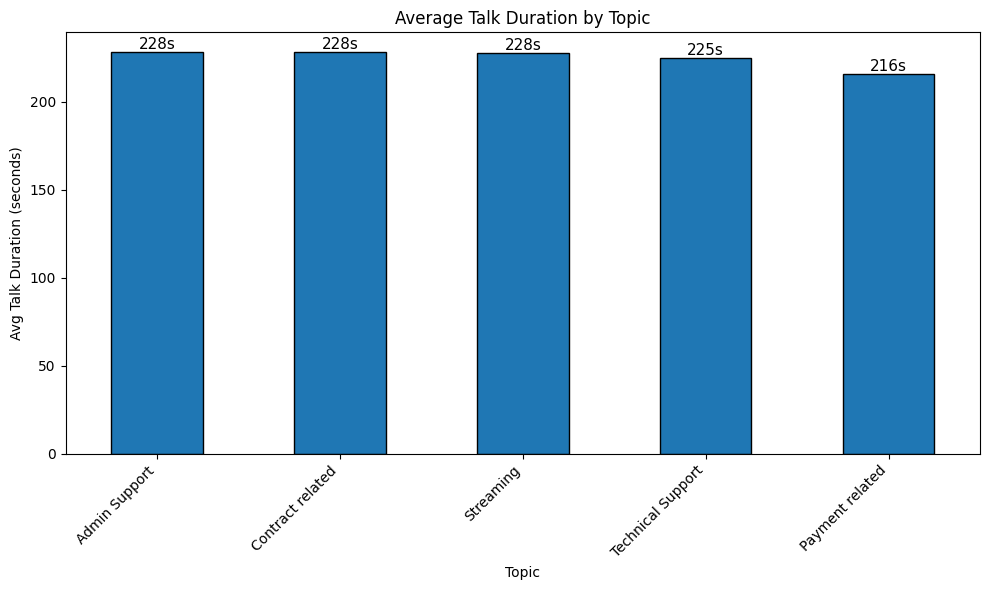

In [398]:
# Get topic columns
topic_cols = [col for col in encoded_df.columns if col.startswith('Topic_')]

# Reconstruct topic name for each row
def get_topic(row):
    for col in topic_cols:
        if row[col]:
            return col.replace('Topic_', '')
    return 'Admin Support'  # drop_first=True dropped this one, so it's the baseline

encoded_df['Topic'] = encoded_df.apply(get_topic, axis=1)

# Average talk duration by topic
avg_by_topic = encoded_df.groupby('Topic')['AvgTalkDuration'].mean().sort_values(ascending=False)
print(avg_by_topic)

# Bar plot
ax = avg_by_topic.plot(kind='bar', figsize=(10, 6), edgecolor='black')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}s',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.title('Average Talk Duration by Topic')
plt.xlabel('Topic')
plt.ylabel('Avg Talk Duration (seconds)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Advtalkduration by day

Date
Tuesday      229.525271
Thursday     227.003454
Sunday       226.481293
Saturday     225.408795
Monday       224.643879
Friday       222.305861
Wednesday    218.737132
Name: AvgTalkDuration, dtype: float64


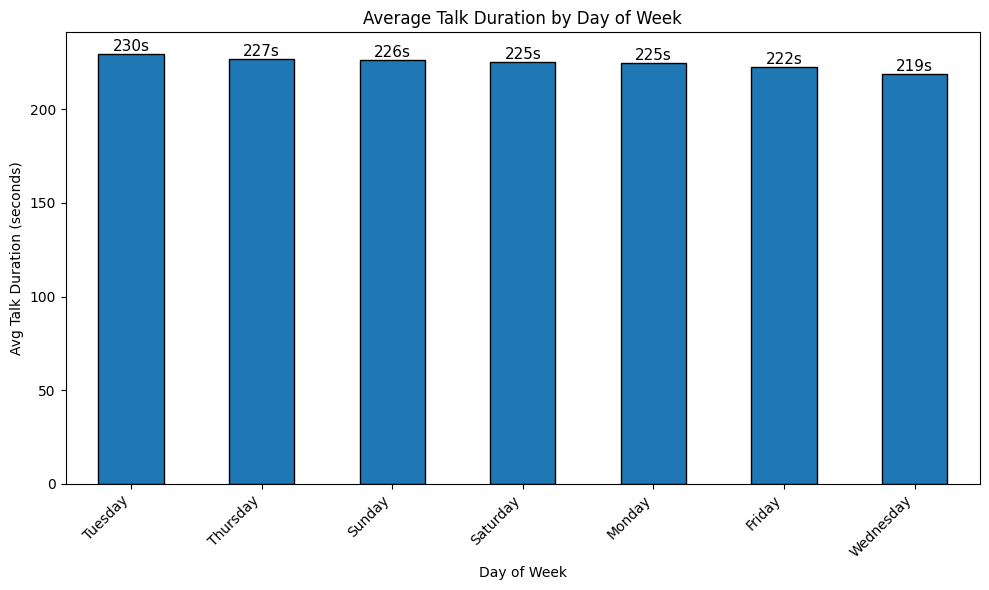

In [406]:
# Get topic columns
topic_cols = [col for col in encoded_df.columns if col.startswith('Date_')]

# Reconstruct topic name for each row
def get_topic(row):
    for col in topic_cols:
        if row[col]:
            return col.replace('Date_', '')
    return 'Friday'  # drop_first=True dropped this one, so it's the baseline

encoded_df['Date'] = encoded_df.apply(get_topic, axis=1)

# Average talk duration by topic
avg_by_topic = encoded_df.groupby('Date')['AvgTalkDuration'].mean().sort_values(ascending=False)
print(avg_by_topic)

# Bar plot
ax = avg_by_topic.plot(kind='bar', figsize=(10, 6), edgecolor='black')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}s',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.title('Average Talk Duration by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Avg Talk Duration (seconds)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Concerned outliers may be affecting the numbers checking for the median

Encode is causing issues will need to pull in data fresh


In [ ]:
# Load the dataset directly from a URL
df = pd.read_excel('https://github.com/globalsmile/Call-Center-Analysis/raw/main/01%20Call-Center-Dataset.xlsx')

print("--- First 5 Rows ---")
print(df.head())
print("--- Last 5 Rows ---")
print(df.tail())

***Git hub not pulling*** made new clean notebook**